# Get Cells

# Compute DV

In [108]:
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
def plot_disease_vectors(df, disease_label, labels, palette_dict, reduction='umap', endotype_matching=False,
               figure_size=(8,6), marker_size=40, save_path=None, alpha=0.8, lw=0.1, fontsize=12, eps=5.0, min_samples=50,
                largest_cluster_arrows=True, explained_var=None, dpi=300):

    if endotype_matching:
        print('Cluster removal filtration epsilon', eps, "min and max", df[['UMAP1','UMAP2']].min().tolist(), df[['UMAP1','UMAP2']].max().tolist())
        keep_indices = []
        for (cell_type, disease), g in df.groupby(['cell_type','disease']):
            lab = DBSCAN(eps=eps, min_samples=min_samples).fit(g[['UMAP1','UMAP2']]).labels_
            s = pd.Series(lab, index=g.index)
            if (s!=-1).any():
                main = s[s!=-1].value_counts().idxmax()
                keep_indices.append(s.index[s==main])
        if len(keep_indices)==0:
            return
        keep_indices = np.concatenate([i.values for i in keep_indices])
        df_plot = df.loc[keep_indices]
    else: df_plot = df

    if largest_cluster_arrows:
        keep_indices = []
        for (cell_type, disease), g in df.groupby(['cell_type','disease']):
            lab = DBSCAN(eps=eps, min_samples=min_samples).fit(g[['UMAP1','UMAP2']]).labels_
            s = pd.Series(lab, index=g.index)
            if (s!=-1).any():
                main = s[s!=-1].value_counts().idxmax()
                keep_indices.append(s.index[s==main])
        if len(keep_indices)==0:
            return
        keep_indices = np.concatenate([i.values for i in keep_indices])
        df_arrows = df.loc[keep_indices]
    else:
        df_arrows = df_plot

    fig, ax = plt.subplots(figsize=figure_size, dpi=dpi)
    hue_vals = labels if isinstance(labels, str) else labels.loc[df_plot.index]
    sns.scatterplot(data=df_plot, x='UMAP1', y='UMAP2', hue=hue_vals, palette=palette_dict, s=marker_size, alpha=alpha, ax=ax, linewidth=lw, zorder=1)# edgecolor='k'
    #ax.set_axisbelow(True)
    #ax.set_aspect('equal', adjustable='box')

    disease_vectors = []
    disease_vectors_linear = []
    for cell_type in df_plot['cell_type'].unique():
        normal_cells = df_arrows[(df_arrows['disease'] == 'normal') & (df_arrows['cell_type'] == cell_type)]
        disease_cells = df_arrows[(df_arrows['disease'] == disease_label) & (df_arrows['cell_type'] == cell_type)]
        if len(normal_cells) > 0 and len(disease_cells) > 0:
            normal_centroid_emb = np.array(normal_cells['embedding'].tolist()).mean(axis=0) if 'embedding' in df_plot.columns else None
            disease_centroid_emb = np.array(disease_cells['embedding'].tolist()).mean(axis=0) if 'embedding' in df_plot.columns else None
            if normal_centroid_emb is not None and disease_centroid_emb is not None:
                disease_vectors.append(disease_centroid_emb - normal_centroid_emb)
            normal_centroid = normal_cells[['UMAP1','UMAP2']].mean().values
            disease_centroid = disease_cells[['UMAP1','UMAP2']].mean().values
            disease_vectors_linear.append(disease_centroid - normal_centroid)
            ax.quiver(normal_centroid[0], normal_centroid[1], disease_centroid[0]-normal_centroid[0], disease_centroid[1]-normal_centroid[1],
                       angles='xy', scale_units='xy', scale=1, width=0.01, headwidth=4, headlength=6, headaxislength=4, linewidth=.01, color='black', alpha=0.8)

    arrow_proxy = FancyArrowPatch((0, 0), (1, 0), arrowstyle='-|>', mutation_scale=15, color='black', linewidth=1)
    def make_legend_quiver(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
        return FancyArrowPatch((0, height*0.5), (width, height*0.5), arrowstyle='-|>', mutation_scale=fontsize, color='black', linewidth=1)

    def cosine_sim(a, b): return 1 - cosine(a, b)
    r = cosine_sim(disease_vectors[0], disease_vectors[1]) if len(disease_vectors) == 2 else 0

    handles, legend_labels_ = ax.get_legend_handles_labels()
    handles.append(arrow_proxy)
    legend_labels_.append(f"Disease Vectors ($\\rho$={r:.2f})")
    palette_order = list(palette_dict.keys())
    order = sorted(range(len(handles)-1), key=lambda i: palette_order.index(legend_labels_[i]) if legend_labels_[i] in palette_order else len(palette_order)) + [len(handles)-1]
    legend_labels_ = [' '.join([word.capitalize() for word in x.replace(' disease', '').split(' ')]) for x in legend_labels_]
    legend_labels_ = [' '.join(label.split('_')).replace('Cd4 positive alpha beta t cell', 'Helper T cell').replace('Cd8 positive alpha beta t cell', 'Cytotoxic T cell'
                ).replace("Classical monocyte", "Monocyte").replace('Fibroblast of cardiac tissue', 'Fibroblast'
            ).replace('Cardiac muscle myoblast', 'Myoblast').replace('Cardiac endothelial cell', 'Endothelial Cell'
                ).replace('Arrhythmogenic right ventricular', 'Arrhythmogenic').replace(' cardiomyopathy', '').replace(' disease', '').replace(
                    "Cardiac muscle cell", "Muscle Cell").replace('Myocardial infarction', 'Myocardial Infarction').replace('cell', 'Cell').replace(
                        "Small Cell lung carcinoma", "SCLC").replace("Non small Cell lung carcinoma", "NSCLC").replace("Lung large Cell carcinoma", "LCLC").replace('Oligodendrocyte precursor cell', "Oligodendrocyte")
                 for label in legend_labels_]

    
    legend = ax.legend(np.array(handles)[order].tolist(), np.array(legend_labels_)[order].tolist(), frameon=True, loc='lower left', borderaxespad=0.5, edgecolor='none', framealpha=0.75,
                        handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_quiver)}, fontsize=fontsize)
    for handle in legend.legendHandles:
        if hasattr(handle, "set_markersize"):
            handle.set_markersize(6) 
            handle.set_alpha(1)

    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.2, color='k', zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_linewidth(2)
    ax.set_xlabel(f'{reduction.upper()}1', fontsize=fontsize+2)
    ax.set_ylabel(f'{reduction.upper()}2', fontsize=fontsize+2)
    if explained_var is not None:
        ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=fontsize+1)
        ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=fontsize+1)
    surround_border = 3
    ax.set_xlim(df_plot['UMAP1'].quantile(.01)-surround_border, df_plot['UMAP1'].quantile(.99)+surround_border)
    ax.set_ylim(df_plot['UMAP2'].quantile(.01)-surround_border, df_plot['UMAP2'].quantile(.99)+surround_border)

    # quiver phase space
    if disease_vectors_linear:
        v=np.mean(disease_vectors_linear,axis=0);v=v/np.linalg.norm(v)
        x_min,x_max=df_plot['UMAP1'].min()-surround_border,df_plot['UMAP1'].max()+surround_border
        y_min,y_max=df_plot['UMAP2'].min()-surround_border,df_plot['UMAP2'].max()+surround_border
        n=15
        xg=np.linspace(x_min,x_max,n);yg=np.linspace(y_min,y_max,n);X,Y=np.meshgrid(xg,yg)
        ax.quiver(X,Y,np.full_like(X,v[0]),np.full_like(Y,v[1]),color='gray',alpha=0.75,
                scale_units='xy',scale=1,width=0.004,headwidth=3,headlength=5,
                headaxislength=4,zorder=-100)
    #plt.rc('font', family='serif',size=24)
    #matplotlib.rc('text', usetex=True)
    ax.set_title(' '.join(disease_label.split('_')).title().replace('Covid', 'COVID')+ f" $n = {df_plot.__len__()}$", fontsize=fontsize+1)
    plt.tight_layout()
    plt.savefig(f"../figures/figure4_lung/PCA_{disease_label}_{'_'.join(df_plot['cell_type'].unique().tolist())}.png", dpi=300, transparent=False)
    plt.show()
    return ax

small cell lung carcinoma


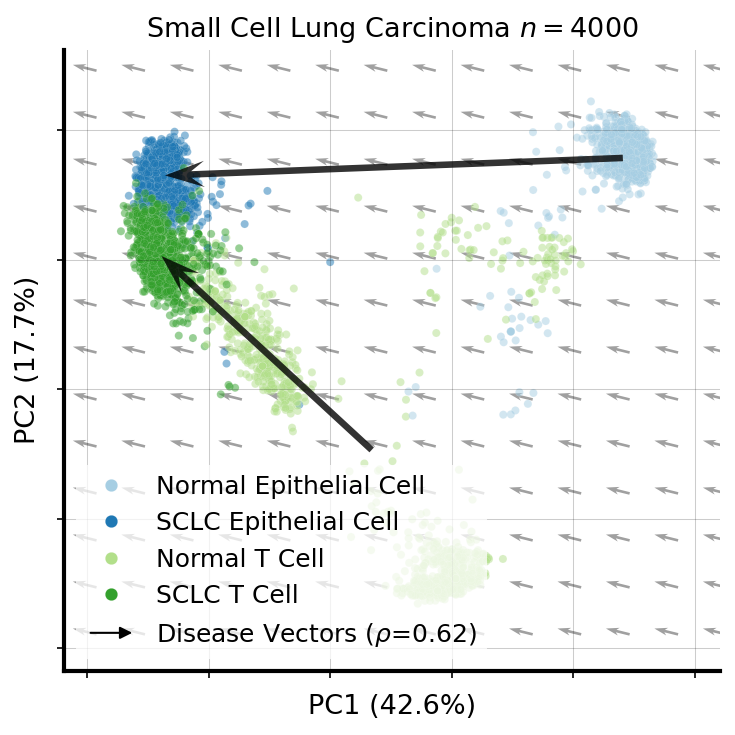

lung large cell carcinoma
Cluster removal filtration epsilon 1 min and max [-10.179063865124503, -14.074795624503876] [9.17239498488611, 6.845327772423472]


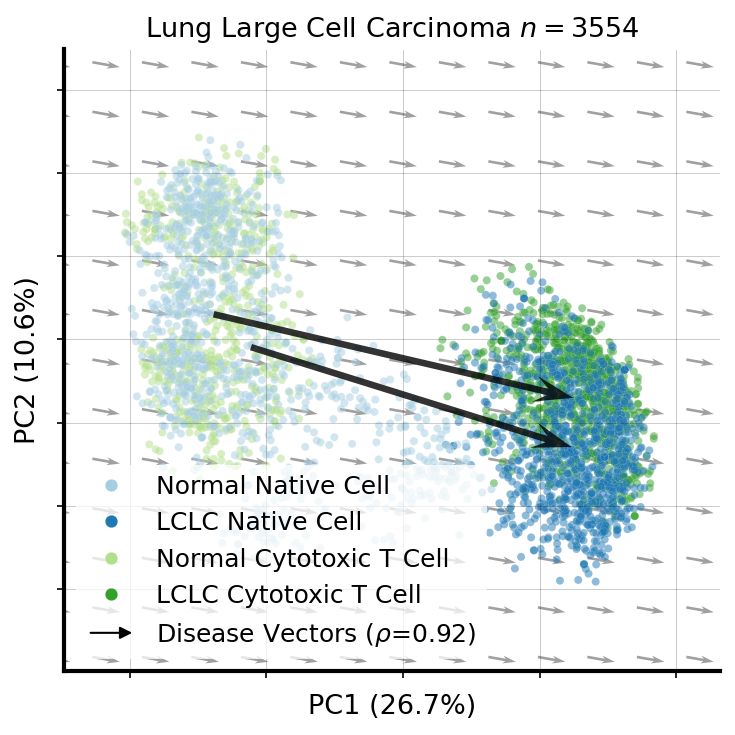

non-small cell lung carcinoma


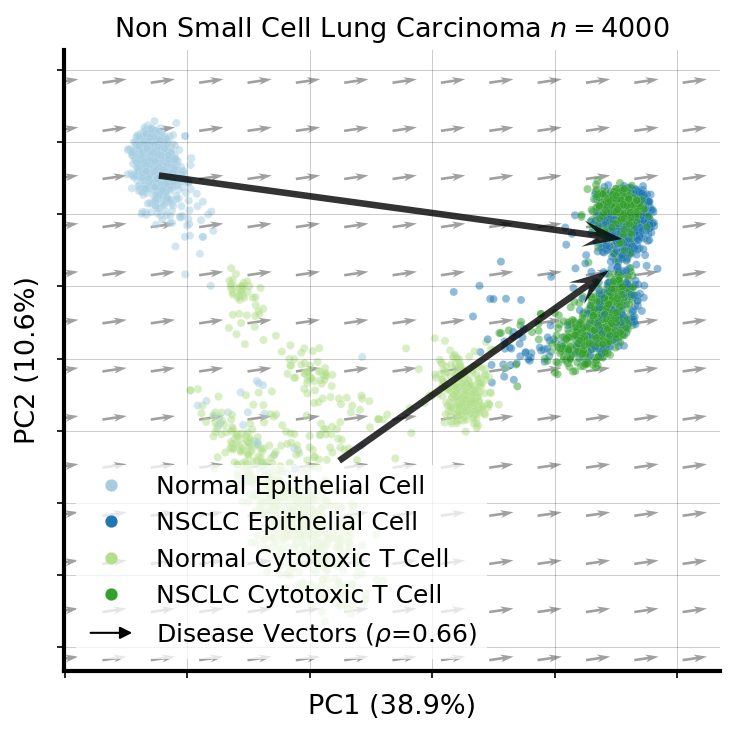

lung adenocarcinoma


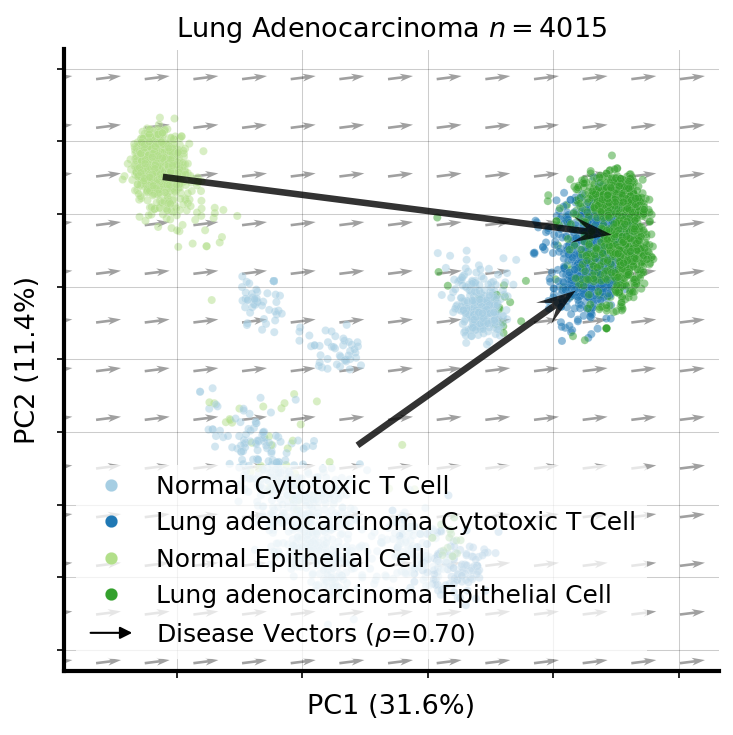

glioblastoma


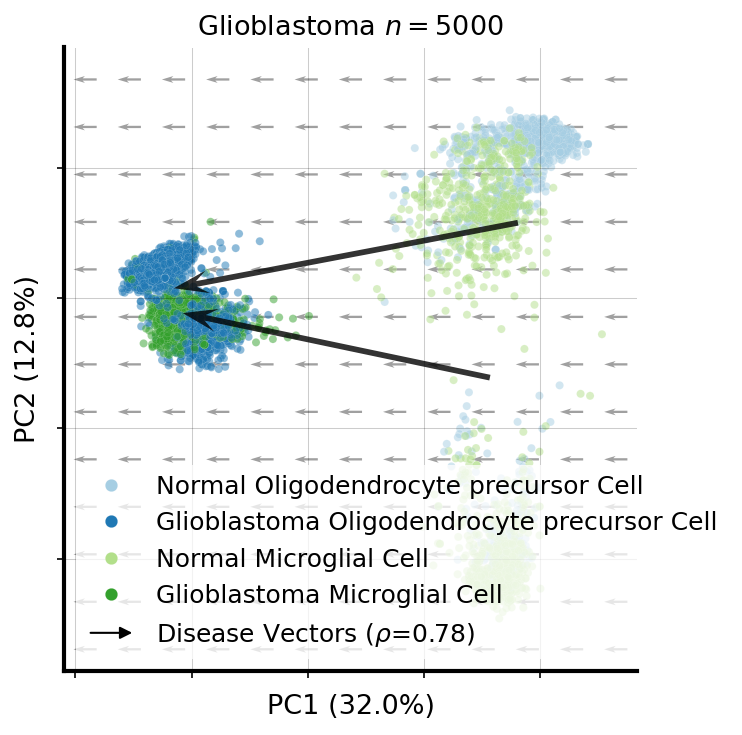

In [109]:
from sklearn.decomposition import PCA
import scanpy as sc, pandas as pd, numpy as np
import itertools
import sys
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
m, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")
phenotypic_types = tok.phenotypic_types
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_geometry/vectors/'
diseases = ['small cell lung carcinoma', 'lung large cell carcinoma', 'non-small cell lung carcinoma', 'lung adenocarcinoma', 'glioblastoma']

for disease in diseases: 
        if disease == 'normal': continue
        print(disease)
        embeddings = pd.read_pickle(EMBEDDINGS_DIR + disease + "_embeddings.pkl")
        df = pd.DataFrame({'embedding': embeddings[0].tolist(), 'y_pred': embeddings[1].tolist()}
                        | {phenotypic_types[idx]:embeddings[2][:, idx] for idx in range(len(phenotypic_types))})
        df[['disease', 'cell_type']] = df[['disease', 'cell_type']].applymap(lambda x: x[1:-1])

        df['cell_type'] = df['cell_type'].apply(lambda x: x.replace('epithelial_cell_of_lower_respiratory_tract', 'epithelial_cell') )
        if disease == "glioblastoma":
                df['cell_type'] = df['cell_type'].apply(lambda x: x.replace('malignant_cell', 'oligodendrocyte_precursor_cell') )
        if disease == "non-small cell lung carcinoma":
                df['cell_type'] = df['cell_type'].apply(lambda x: x.replace('malignant_cell', 'epithelial_cell') )
        if disease == "lung adenocarcinoma":
                df['cell_type'] = df['cell_type'].apply(lambda x: x.replace('malignant_cell', 'epithelial_cell') )
        disease_cell_types = df['cell_type'].unique().tolist()

        disease = normalise_str(disease)[1:-1]
        for cell_type_pair in itertools.combinations(disease_cell_types, 2):
                ds = df[(df['disease'].isin([disease, 'normal'])) & (df['cell_type'].isin(cell_type_pair))].copy()
                proj = PCA(2)
                ds.loc[:, ['UMAP1', 'UMAP2']] = proj.fit_transform(np.array(ds['embedding'].tolist())).tolist()
                explained_var = proj.explained_variance_ratio_
                labels = ds.apply(lambda x: f"{x['disease']} {x['cell_type']}", axis=1)
                palette_dict = {f"{cond} {c}": sns.color_palette('Paired', 30)[2*i + j]
                        for i, c in enumerate(cell_type_pair) for j, cond in enumerate(["normal", disease])}
                ax = plot_disease_vectors(ds, disease, labels, palette_dict, figure_size=(5, 5),
                                reduction="pc", fontsize=12, endotype_matching=True if disease == "lung_large_cell_carcinoma" else False,
                                  marker_size=15, alpha=0.5, 
                                  min_samples=20,eps=1, largest_cluster_arrows=False, explained_var = explained_var, dpi=150, lw=0.1)
                


In [65]:
import pandas as pd
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_geometry/vectors/'
results = pd.read_pickle(EMBEDDINGS_DIR + "disease_vectors.pkl")
similarity_matrices = pd.read_pickle( EMBEDDINGS_DIR + "similarity_matrices.pkl")

In [88]:
dv.sample()

,small_cell_lung_carcinoma t_cell,small_cell_lung_carcinoma epithelial_cell,lung_large_cell_carcinoma cd8_positive_alpha_beta_t_cell,lung_large_cell_carcinoma native_cell,non_small_cell_lung_carcinoma cd8_positive_alpha_beta_t_cell,non_small_cell_lung_carcinoma malignant_cell,lung_adenocarcinoma cd8_positive_alpha_beta_t_cell,lung_adenocarcinoma malignant_cell,lung_adenocarcinoma epithelial_cell_of_lower_respiratory_tract,glioblastoma microglial_cell,glioblastoma oligodendrocyte_precursor_cell,glioblastoma malignant_cell
anndata_obs_pairs,"[(40326850, 40819375), (22865463, 40880401), (...","[(58646501, 40763993), (58757101, 40775913), (...","[(13428356, 14680803), (34230433, 14339759), (...","[(13410476, 14503737), (14425603, 14193967), (...","[(15230506, 34368164), (34346178, 34369701), (...","[(58754772, 34394342), (58758014, 34391125), (...","[(15198447, 34821857), (14238379, 14054482), (...","[(58775839, 34834139), (58750347, 34733682), (...","[(58775839, 15198928), (58750347, 15249687), (...","[(18449748, 36350126), (4488722-2, 36527146), ...","[(5287473, 36938733), (23223909, 36944439), (2...","[(5287473, 36691703), (23223909, 36889095-1), ..."


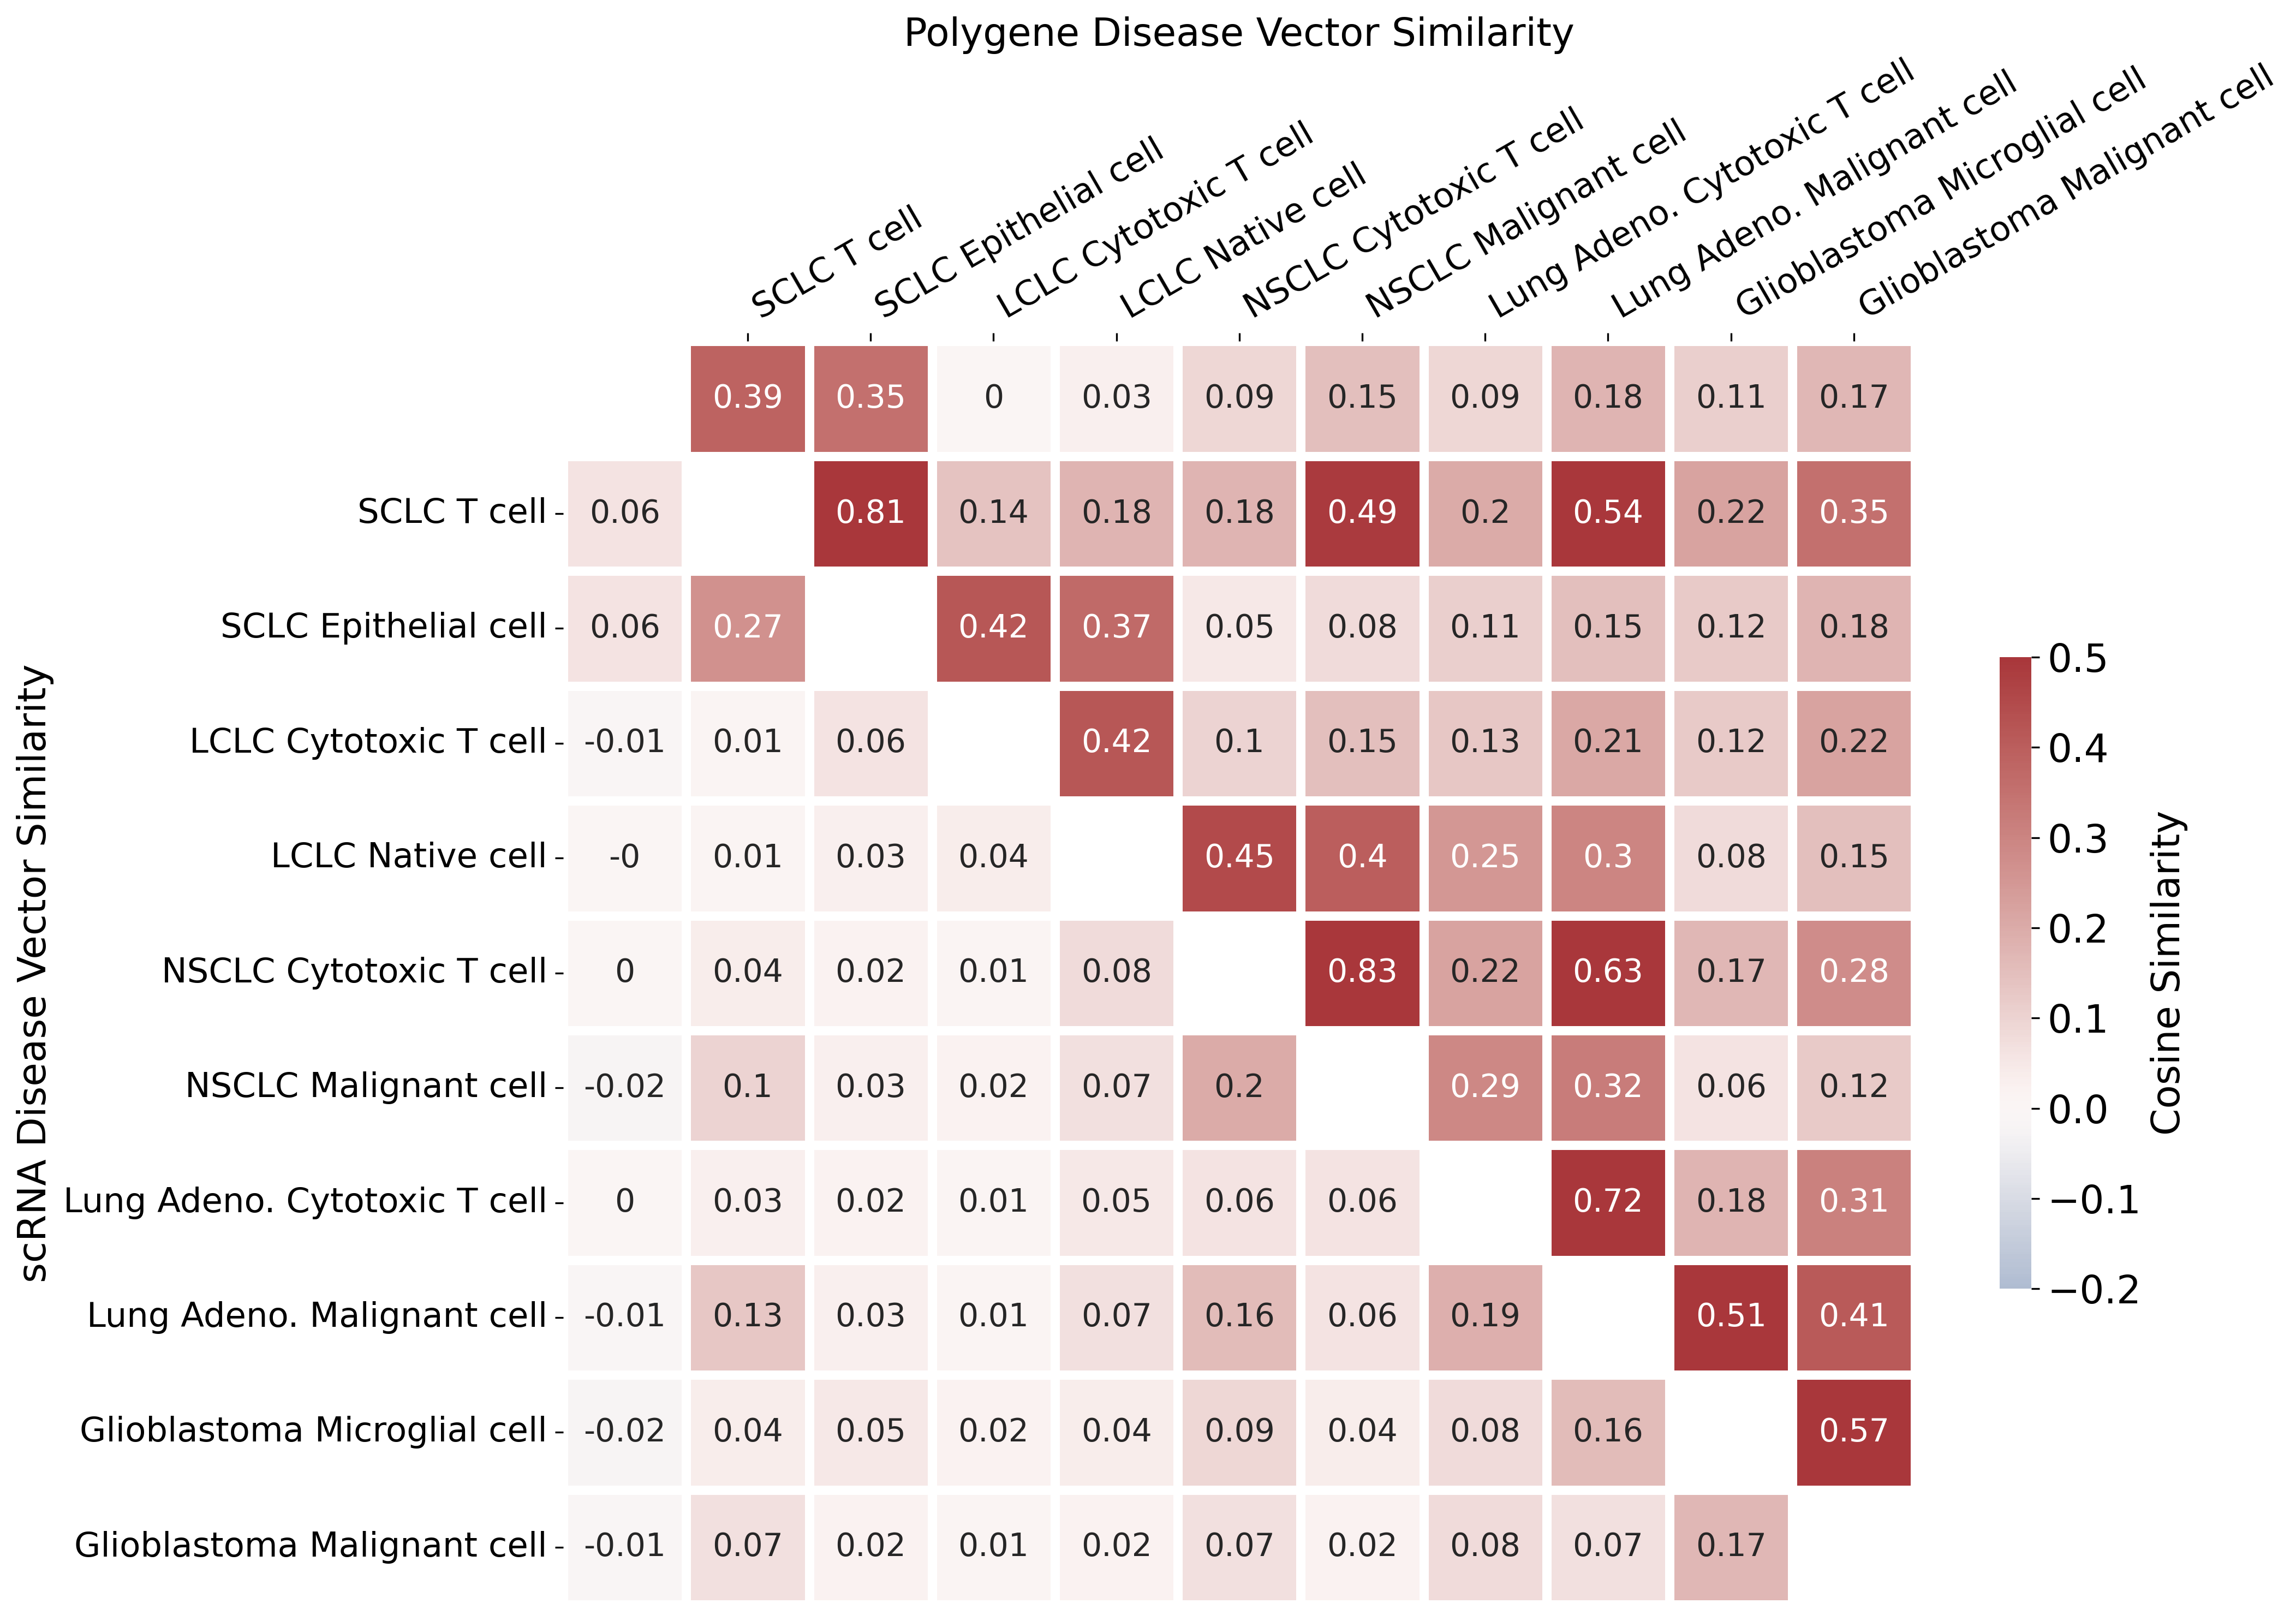

In [103]:
import matplotlib.pyplot as plt, seaborn as sns, numpy as np, pandas as pd

fontsize=15
palette = "magma"
palette = "viridis"
palette = "RdYlBu_r" # "vlag"
palette = "coolwarm"
palette = "vlag"
round_digits = 2

vector_type = "vectors"
matrix = similarity_matrices["vectors"]
subset_select_diseases = ['lung', 'glioblastoma',]
dv = pd.DataFrame(results)
disease_selection = [col for col in dv.columns if any(sub.lower() in col.lower() for sub in subset_select_diseases)
                      and col.lower() != "lung_adenocarcinoma epithelial_cell_of_lower_respiratory_tract" and col.lower() != "glioblastoma oligodendrocyte_precursor_cell"]

matrix = similarity_matrices[f"{vector_type}"].loc[disease_selection, disease_selection]
matrix_raw = similarity_matrices[f"raw_{vector_type}"].loc[disease_selection, disease_selection]

plot_matrix = np.zeros((len(matrix) + 1 , len(matrix) + 1))
plot_matrix[:-1, 1:] = np.triu(matrix)
plot_matrix[1:, :-1] += np.tril(matrix_raw)
np.fill_diagonal(plot_matrix, np.nan)


#plot_matrix = np.triu(matrix)
fig, ax = plt.subplots(1,1, figsize=(14, 10), dpi= 300)
labels = [' '.join([word.capitalize() for word in x.replace(' disease', '').split(' ')]) for x in matrix.columns]
labels = [' '.join(label.split('_'))
                    .replace('Cd4 positive alpha beta t cell', 'Helper T cell').replace('Cd8 positive alpha beta t cell', 'Cytotoxic T cell'
                ).replace("Classical monocyte", "Monocyte").replace('Fibroblast of cardiac tissue', 'Fibroblast'
            ).replace('Cardiac muscle myoblast', 'Myoblast').replace('Cardiac endothelial cell', 'Endothelial Cell'
                ).replace('Arrhythmogenic right ventricular', 'Arrhythmogenic').replace(' cardiomyopathy', '').replace(' disease', '').replace(
                    "Cardiac muscle cell", "Muscle Cell").replace('Myocardial infarction', 'Myocardial Infarction').replace(
                    "Epithelial cell of lower respiratory tract", "Epithelial cell").replace('Oligodendrocyte precursor cell', 'Oligodendrocyte').replace(
                        "Small cell lung carcinoma", "SCLC").replace("Non small cell lung carcinoma", "NSCLC").replace("Lung large cell carcinoma", "LCLC").replace('Lung adenocarcinoma', 'Lung Adeno.')
                      for label in labels]


vmin, vmax, center = (-0.2, .5, 0)
sns.heatmap(plot_matrix.round(round_digits), annot=True, cmap=palette, center=center, vmin=vmin, vmax=vmax,
                xticklabels=[''] + labels, yticklabels=[''] + labels, annot_kws={"size": fontsize-1},ax=ax, lw=4,  cbar_kws={"shrink": 0.5, "aspect":20})
cbar = ax.collections[0].colorbar
cbar.set_label("Cosine Similarity", fontsize=fontsize+2)
cbar.ax.tick_params(labelsize=fontsize+2)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.setp(ax.get_xticklabels(), rotation=30, ha="left", fontsize=fontsize)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=fontsize)
plt.xlabel("Polygene Disease Vector Similarity", fontsize=fontsize + 2, y=1)
plt.ylabel("scRNA Disease Vector Similarity", fontsize=fontsize + 2  )
for tick in ax.xaxis.get_major_ticks()[0:1]:
    tick.tick1line.set_visible(False)
    tick.tick2line.set_visible(False)
for tick in ax.yaxis.get_major_ticks()[0:1]:
    tick.tick1line.set_visible(False)
    tick.tick2line.set_visible(False)
plt.tight_layout()
plt.savefig(f'../figures/figure4_lung/similarity_heatmap.svg', dpi=300, transparent=True)
plt.show()